In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv(r'perrin-freres-monthly-champagne.csv', index_col = 'Month', parse_dates = True, skipfooter = 2)

C:\Users\VARUN\AppData\Local\Temp\ipykernel_16248\3624895953.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(r'perrin-freres-monthly-champagne.csv', index_col = 'Month', parse_dates = True, skipfooter = 2)


In [4]:
df.head()

,Perrin Freres monthly champagne sales millions ?64-?72
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


In [6]:
df.columns = ['Sales']

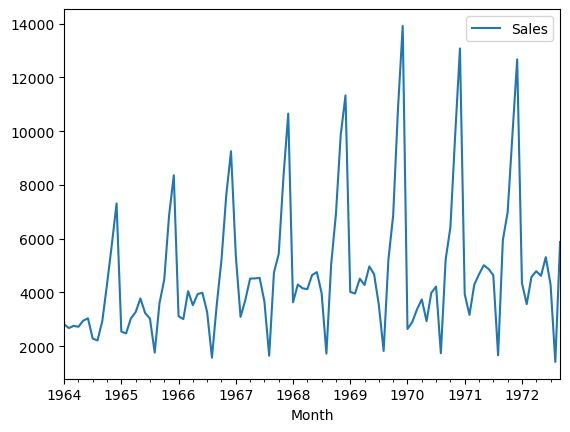

In [9]:
df.plot();

In [10]:
df.index

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='Month', length=105, freq=None)

In [11]:
df.index.freq = 'MS'

In [12]:
Ntest = 12
train =  df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [13]:
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]
test_idx

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [14]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [15]:
hw = ExponentialSmoothing( 
    train['Sales'], 
    initialization_method = 'legacy-heuristic',
    trend ='add', seasonal = 'add', seasonal_periods = 12)
res_hw = hw.fit()

In [16]:
df.loc[train_idx, 'HoltWintersTrain'] = res_hw.fittedvalues
df.loc[test_idx, 'HoltWintersTest'] = res_hw.forecast(Ntest)

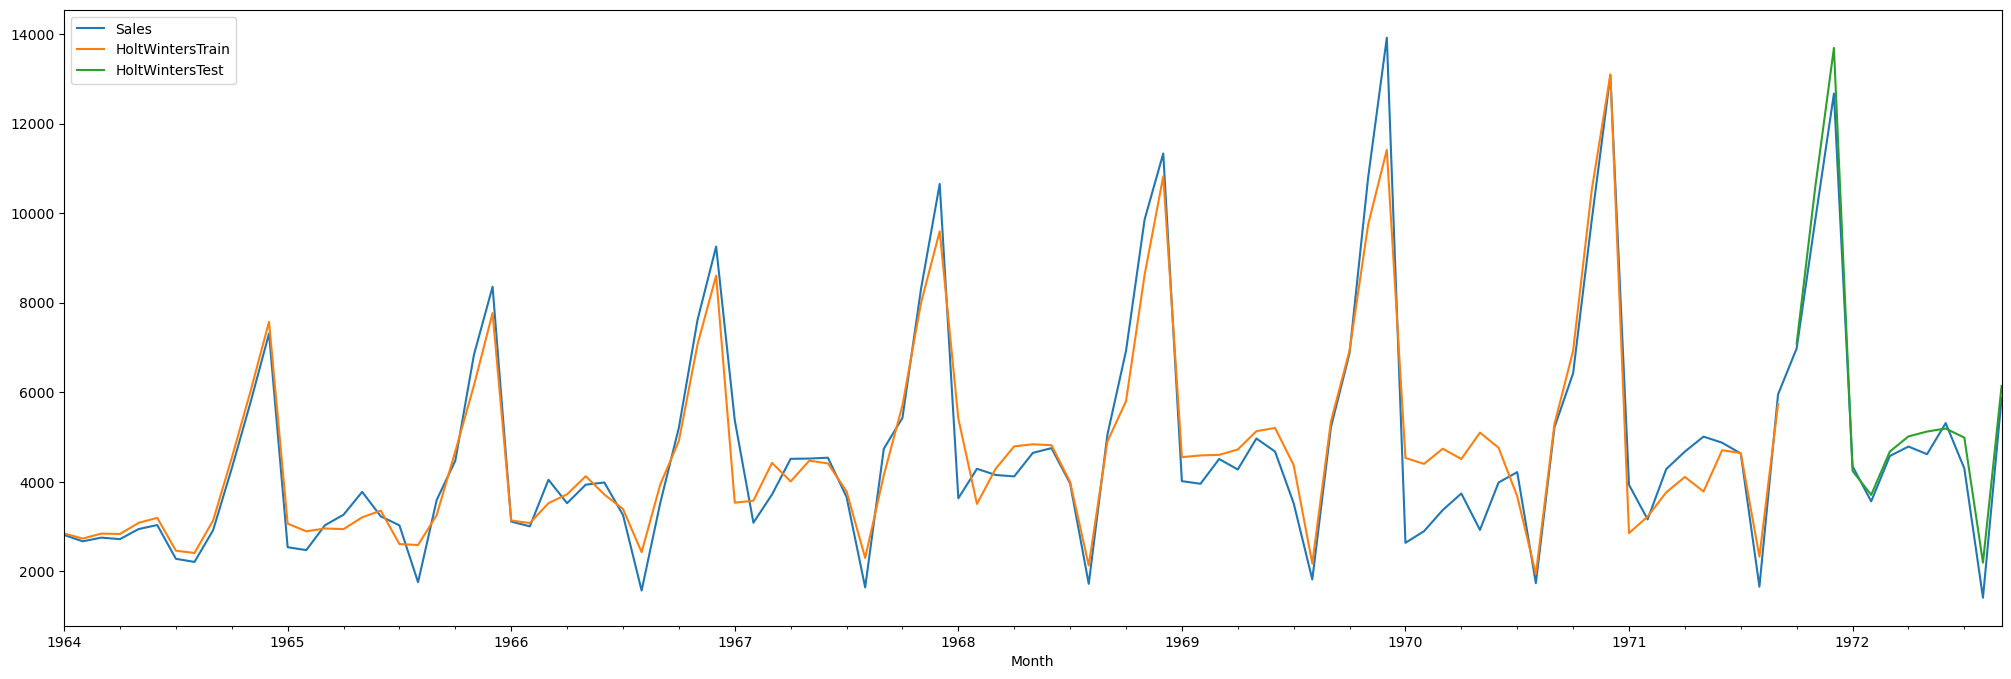

In [18]:
df[['Sales','HoltWintersTrain','HoltWintersTest']].plot(figsize = (25,8));

In [19]:
r2_score(train['Sales'], res_hw.fittedvalues)

0.9170005799930573

In [20]:
r2_score(test['Sales'], res_hw.forecast(Ntest))

0.9681244396657379

# try other options and see if performance improves, also see other metrices

# lastly, walk forward validation is required in order see the best hyperparameter combinations and see if for each hyperparameter, the metrics for each iteration within walkforward is close to each other and not fluctuating